# 6.1 Polls — EDA

Exploratory analysis of 256 nationwide polls (Jul–Nov 2024) from Wikipedia.

**Pipeline:** Bronze → Analysis  
**Input:** `Data/1_Bronze/Polls/wikipedia_polls.csv`  
**Output:** –

<!-- toc -->
## Contents
- [Setup](#setup)
- [1. Rolling Average Over Time](#1-rolling-average-over-time)
  - [Presentation: Polls with and without Polymarket Overlay](#presentation-polls-with-and-without-polymarket-overlay)
- [2. Margin Over Time](#2-margin-over-time)
- [3. Distribution](#3-distribution)
- [4. Monthly Averages](#4-monthly-averages)
- [5. Pollster Bias](#5-pollster-bias)
- [Summary](#summary)


## Setup

In [1]:
import sys
sys.path.insert(0, '../..')
from house_style import *
import warnings
warnings.filterwarnings('ignore')

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

apply_style()

In [2]:
df = pd.read_csv('../../Data/1_Bronze/Polls/wikipedia_polls.csv', parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df['Pollster_clean'] = df['Pollster'].astype(str).apply(lambda s: re.sub(r'\[.*?\]', '', s).strip())

print(f"Polls : {len(df)}  |  {df['Date'].min().date()} → {df['Date'].max().date()}")
df[['Trump', 'Harris', 'Margin']].describe().round(2)

Polls : 256  |  2024-06-24 → 2024-11-04


,Trump,Harris,Margin
count,256.00,256.00,256.00
mean,46.72,47.89,-1.16
std,2.41,2.74,3.03
min,37.00,38.00,-8.00
25%,45.00,46.78,-4.00
50%,47.00,48.00,-1.00
75%,48.00,50.00,1.00
max,53.00,53.00,7.00


In [3]:
print(f"Trump leads  : {(df['Trump'] > df['Harris']).sum()} polls")
print(f"Harris leads : {(df['Trump'] < df['Harris']).sum()} polls")
print(f"Tied         : {(df['Trump'] == df['Harris']).sum()} polls")

Trump leads  : 83 polls
Harris leads : 151 polls
Tied         : 22 polls


## 1. Rolling Average Over Time

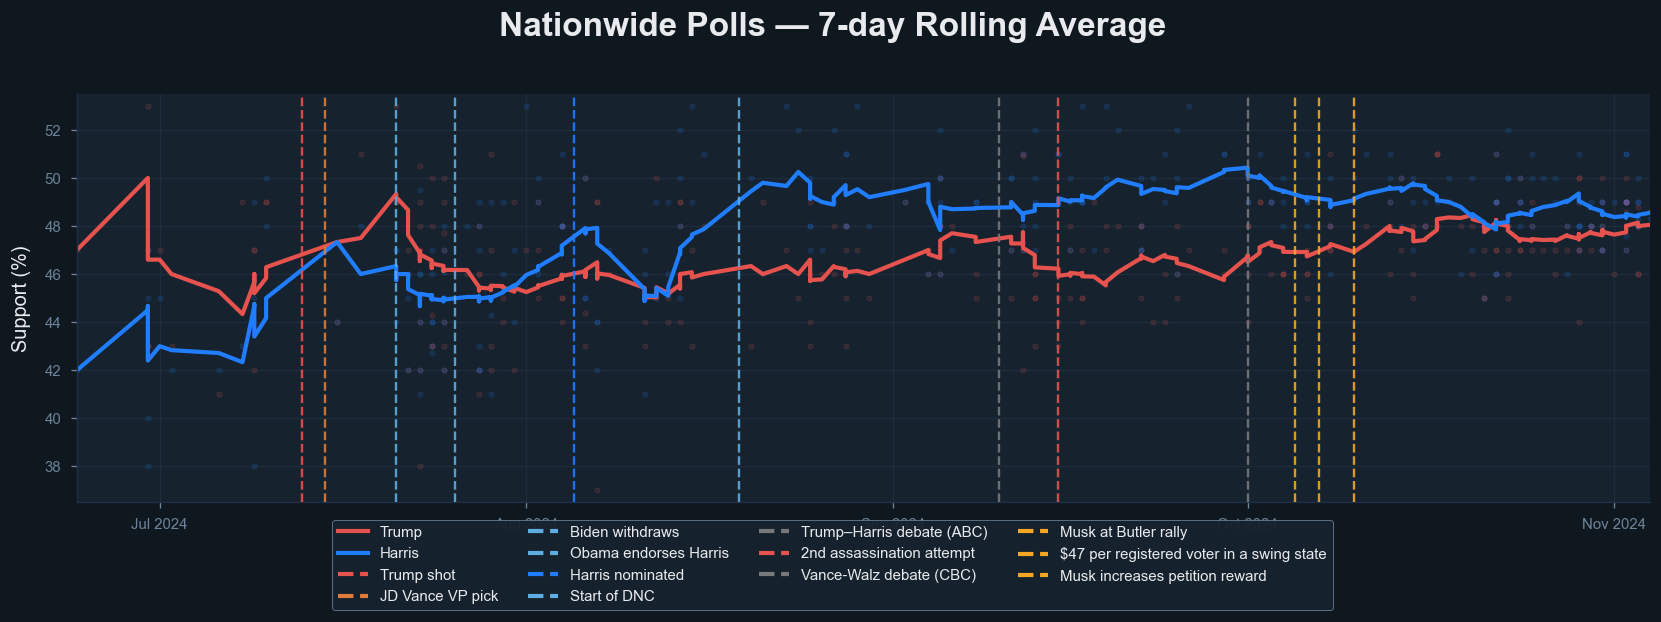

In [4]:
df_plot     = df.dropna(subset=['Trump','Harris']).set_index('Date').sort_index()
trump_roll  = df_plot['Trump'].rolling('7D',  min_periods=1).mean()
harris_roll = df_plot['Harris'].rolling('7D', min_periods=1).mean()

fig, ax = styled_fig(figsize=(14, 5), title='Nationwide Polls — 7-day Rolling Average')

ax.scatter(df_plot.index, df_plot['Trump'],  color=REPUBLICAN, alpha=0.15, s=10, zorder=2)
ax.scatter(df_plot.index, df_plot['Harris'], color=DEMOCRAT,   alpha=0.15, s=10, zorder=2)
ax.plot(trump_roll,  color=REPUBLICAN, linewidth=2.5, label='Trump')
ax.plot(harris_roll, color=DEMOCRAT,   linewidth=2.5, label='Harris')

add_events(ax)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
style_ax(ax, ylabel='Support (%)', grid_axis='y')

from matplotlib.lines import Line2D
data_h = [Line2D([],[],color=REPUBLICAN,linewidth=2.5,label='Trump'),
          Line2D([],[],color=DEMOCRAT,  linewidth=2.5,label='Harris')]
fig.legend(handles=data_h + event_legend_handles(),
           loc='lower center', bbox_to_anchor=(0.5,0.01),
           ncol=4, facecolor=BG_PANEL, edgecolor=TEXT_MUTED,
           labelcolor=TEXT_PRIMARY, fontsize=9, framealpha=0.95)
plt.tight_layout(rect=[0,0.12,1,1])
plt.show()

Harris leads in 151 of the 256 polls, Trump in 83. In June (Biden still the candidate) Trump was ahead, but after his withdrawal (Jul 21) the trend reversed. From August onwards Harris holds a consistent lead that she maintains through to election day.

### Presentation: Polls with and without Polymarket Overlay

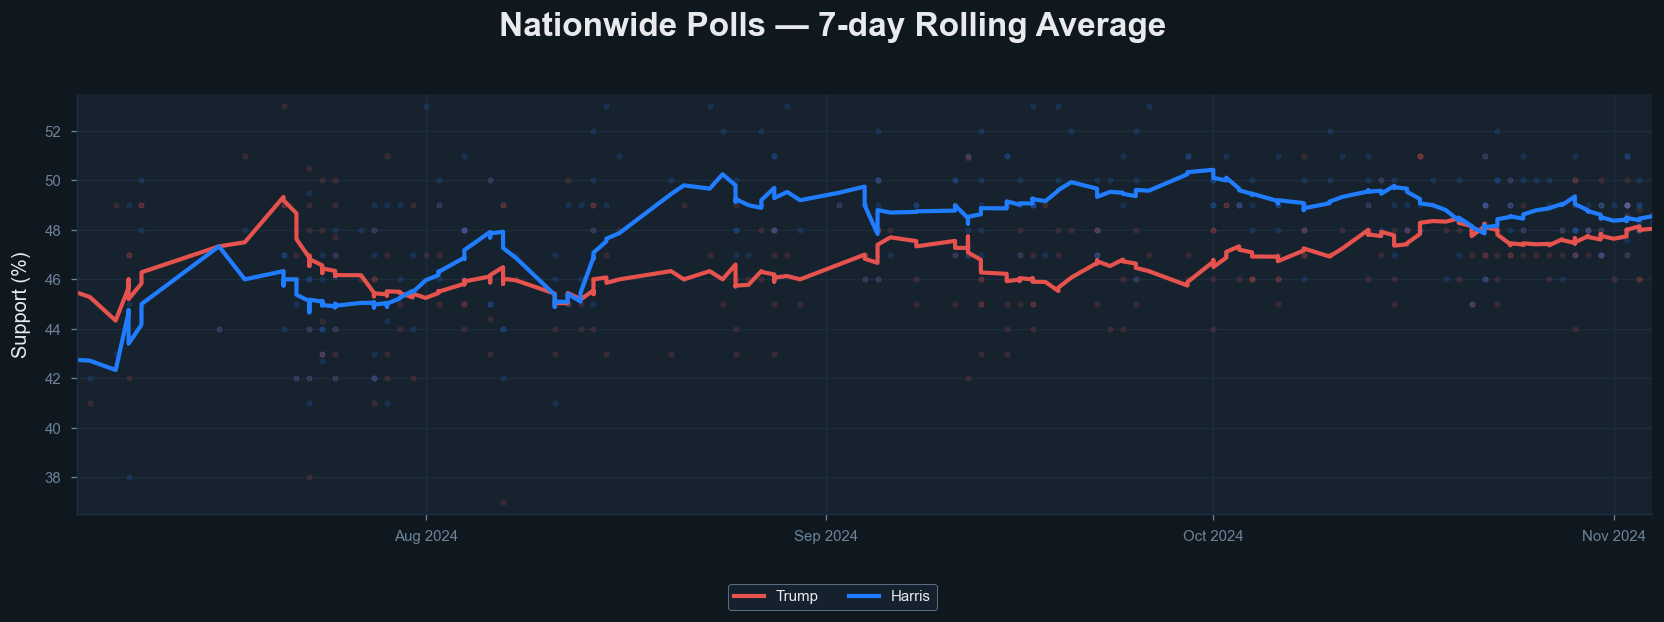

In [5]:
fig, ax = styled_fig(figsize=(14, 5), title='Nationwide Polls — 7-day Rolling Average')

ax.scatter(df_plot.index, df_plot['Trump'],  color=REPUBLICAN, alpha=0.15, s=10, zorder=2)
ax.scatter(df_plot.index, df_plot['Harris'], color=DEMOCRAT,   alpha=0.15, s=10, zorder=2)
ax.plot(trump_roll,  color=REPUBLICAN, linewidth=2.5, label='Trump')
ax.plot(harris_roll, color=DEMOCRAT,   linewidth=2.5, label='Harris')

ax.set_xlim(pd.Timestamp('2024-07-05'), pd.Timestamp('2024-11-04'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
style_ax(ax, ylabel='Support (%)', grid_axis='y')

data_h = [Line2D([],[],color=REPUBLICAN, linewidth=2.5, label='Trump'),
          Line2D([],[],color=DEMOCRAT,   linewidth=2.5, label='Harris')]
fig.legend(handles=data_h, loc='lower center', bbox_to_anchor=(0.5, 0.01),
           ncol=2, facecolor=BG_PANEL, edgecolor=TEXT_MUTED,
           labelcolor=TEXT_PRIMARY, fontsize=9, framealpha=0.95)
plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()


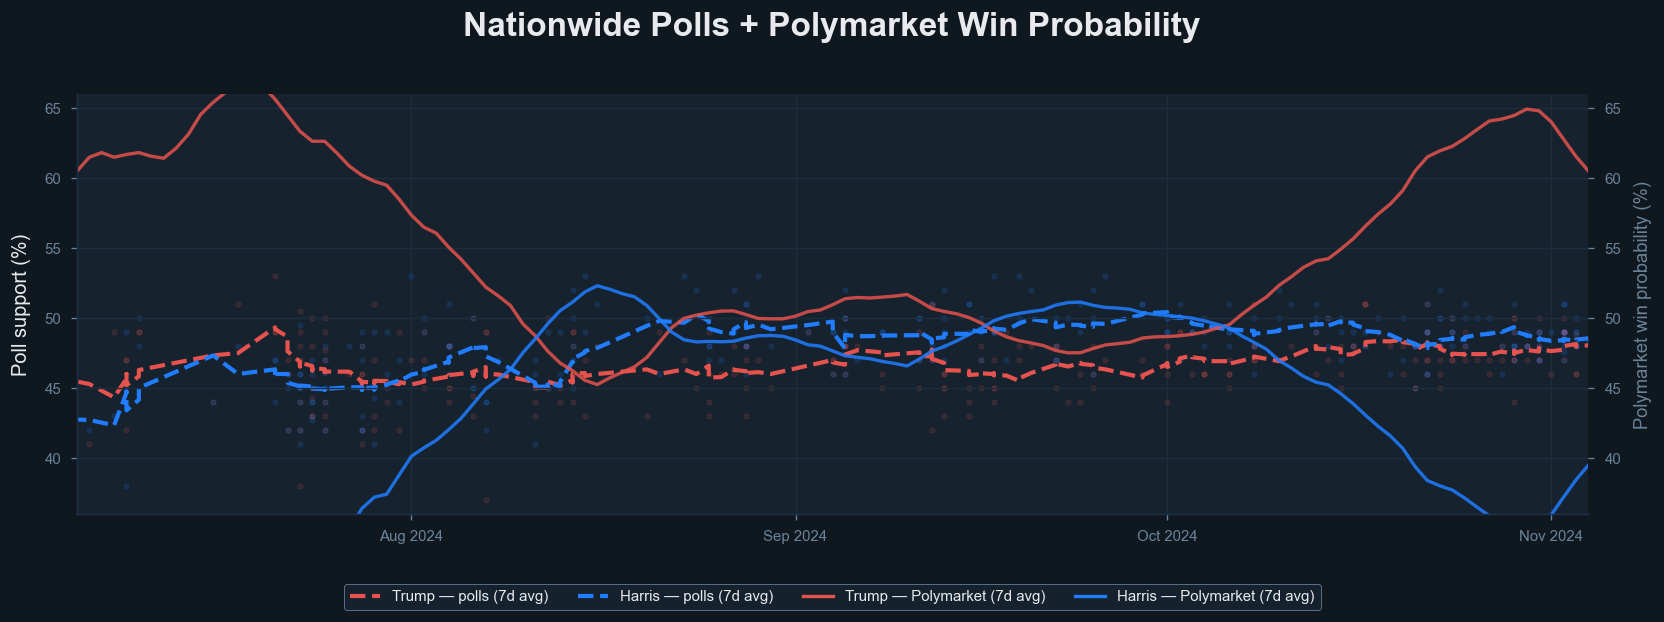

In [7]:
pm = pd.read_csv('../../Data/1_Bronze/Polymarket/polymarket_win_probabilities.csv',
                 parse_dates=['date'])
pm = pm[(pm['date'] >= '2024-07-05') & (pm['date'] <= '2024-11-04')].sort_values('date')

pm_trump_roll  = pm.set_index('date')['Trump (%)'].rolling('7D', min_periods=1).mean()
pm_harris_roll = pm.set_index('date')['Harris (%)'].rolling('7D', min_periods=1).mean()

fig, ax1 = styled_fig(figsize=(14, 5), title='Nationwide Polls + Polymarket Win Probability')

# Polls (left axis) — scatter + dashed rolling average
ax1.scatter(df_plot.index, df_plot['Trump'],  color=REPUBLICAN, alpha=0.15, s=10, zorder=2)
ax1.scatter(df_plot.index, df_plot['Harris'], color=DEMOCRAT,   alpha=0.15, s=10, zorder=2)
ax1.plot(trump_roll,  color=REPUBLICAN, linewidth=2.5, linestyle='--')
ax1.plot(harris_roll, color=DEMOCRAT,   linewidth=2.5, linestyle='--')
style_ax(ax1, ylabel='Poll support (%)', grid_axis='y')
ax1.set_xlim(pd.Timestamp('2024-07-05'), pd.Timestamp('2024-11-04'))
ax1.set_ylim(36, 66)

# Polymarket (right axis) — solid smoothed lines
ax2 = ax1.twinx()
ax2.plot(pm_trump_roll,  color=REPUBLICAN, linewidth=2, linestyle='-', alpha=0.85)
ax2.plot(pm_harris_roll, color=DEMOCRAT,   linewidth=2, linestyle='-', alpha=0.85)
ax2.set_ylabel('Polymarket win probability (%)', color=TEXT_MUTED, fontsize=11)
ax2.tick_params(axis='y', colors=TEXT_MUTED)
ax2.set_facecolor('none')
ax2.set_ylim(36, 66)

ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator())

legend_handles = [
    Line2D([],[],color=REPUBLICAN, linewidth=2.5, linestyle='--', label='Trump — polls (7d avg)'),
    Line2D([],[],color=DEMOCRAT,   linewidth=2.5, linestyle='--', label='Harris — polls (7d avg)'),
    Line2D([],[],color=REPUBLICAN, linewidth=2,   linestyle='-',  label='Trump — Polymarket (7d avg)'),
    Line2D([],[],color=DEMOCRAT,   linewidth=2,   linestyle='-',  label='Harris — Polymarket (7d avg)'),
]
fig.legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(0.5, 0.01),
           ncol=4, facecolor=BG_PANEL, edgecolor=TEXT_MUTED,
           labelcolor=TEXT_PRIMARY, fontsize=9, framealpha=0.95)
plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()


## 2. Margin Over Time

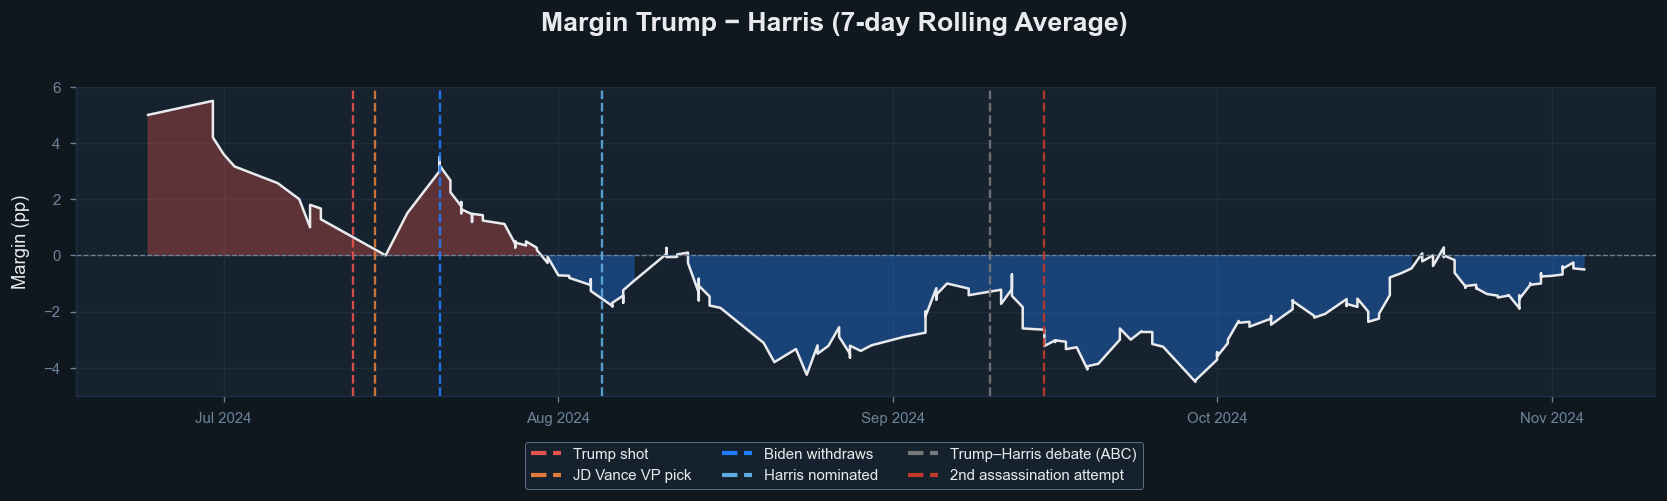

In [5]:
margin_roll = trump_roll - harris_roll

fig, ax = styled_fig(figsize=(14, 4), title='Margin Trump − Harris (7-day Rolling Average)')
ax.fill_between(margin_roll.index, margin_roll, 0,
                where=(margin_roll >= 0), color=REPUBLICAN, alpha=0.35, label='Trump leads')
ax.fill_between(margin_roll.index, margin_roll, 0,
                where=(margin_roll <  0), color=DEMOCRAT,   alpha=0.35, label='Harris leads')
ax.plot(margin_roll, color=TEXT_PRIMARY, linewidth=1.5)
ax.axhline(0, color=TEXT_MUTED, linewidth=0.8, linestyle='--')

add_events(ax)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
style_ax(ax, ylabel='Margin (pp)', grid_axis='y')
fig.legend(handles=event_legend_handles(),
           loc='lower center', bbox_to_anchor=(0.5,0.01),
           ncol=3, facecolor=BG_PANEL, edgecolor=TEXT_MUTED,
           labelcolor=TEXT_PRIMARY, fontsize=9, framealpha=0.95)
plt.tight_layout(rect=[0,0.12,1,1])
plt.show()

Trump leads only in the first few weeks. From late July the margin shifts towards Harris and stays negative (Harris ahead) through November. The gap fluctuates between −1 and −3 pp — narrow but consistent.

## 3. Distribution

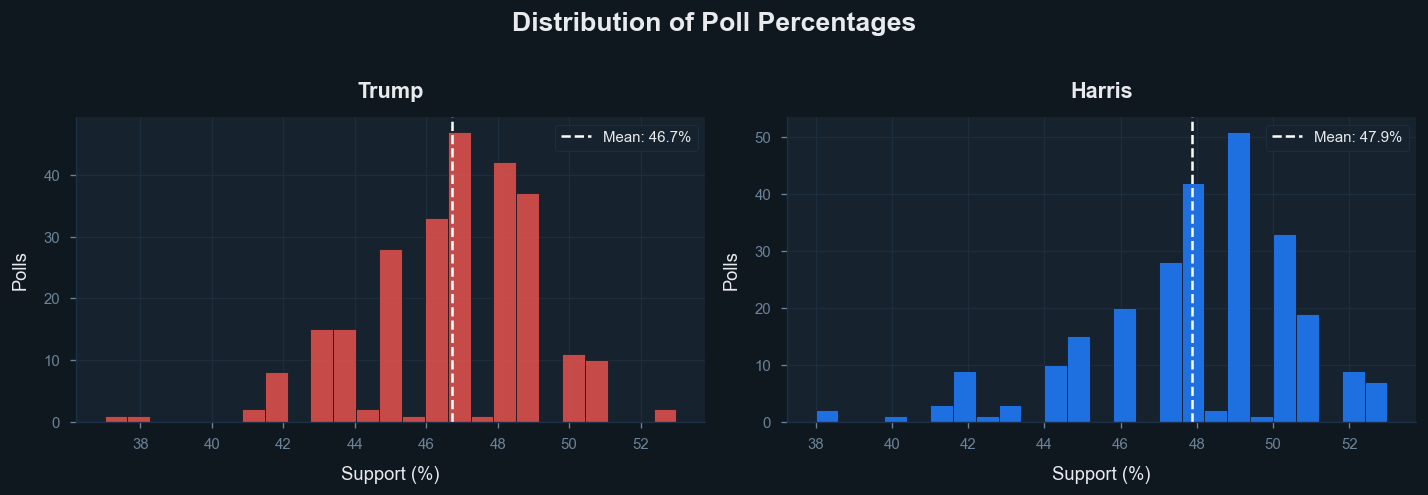

In [6]:
fig, axes = styled_fig(nrows=1, ncols=2, figsize=(12, 4),
                       title='Distribution of Poll Percentages')
for ax, col, color in zip(axes, ['Trump','Harris'], [REPUBLICAN, DEMOCRAT]):
    data = df[col].dropna()
    ax.hist(data, bins=25, color=color, alpha=0.85, edgecolor=BG_DARK)
    ax.axvline(data.mean(), color='white', linestyle='--', linewidth=1.5,
               label=f'Mean: {data.mean():.1f}%')
    style_ax(ax, xlabel='Support (%)', ylabel='Polls', title=col, grid_axis='y')
    ax.legend()
plt.tight_layout()
plt.show()

Trump clusters around 46.7%, Harris around 47.9% — both roughly normally distributed but clearly separated. Harris's 1.2 pp higher average reflects her structural polling advantage across the full period.

## 4. Monthly Averages

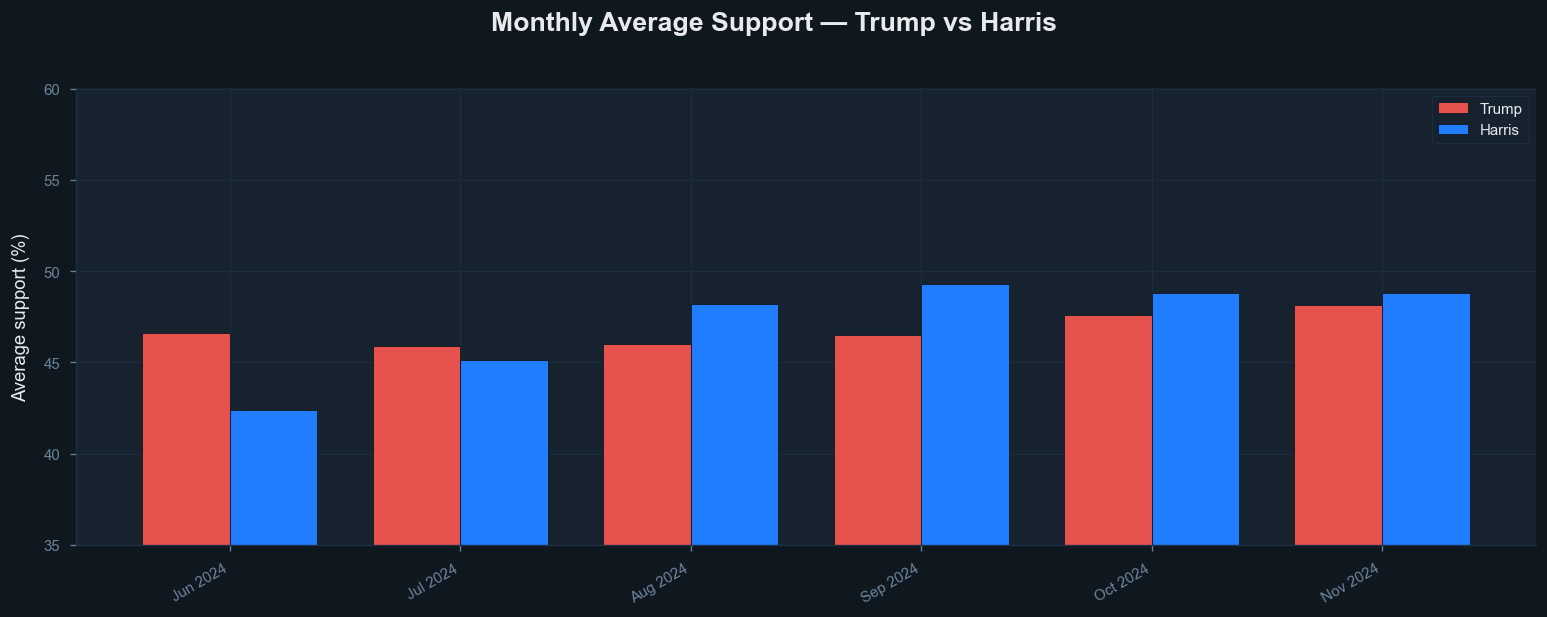

In [7]:
df_monthly = (df.set_index('Date')[['Trump','Harris']]
                .resample('ME').mean().dropna())
labels = df_monthly.index.strftime('%b %Y')
x, w = np.arange(len(labels)), 0.38

fig, ax = styled_fig(figsize=(13, 5), title='Monthly Average Support — Trump vs Harris')
ax.bar(x - w/2, df_monthly['Trump'],  w, color=REPUBLICAN, label='Trump',  edgecolor=BG_DARK)
ax.bar(x + w/2, df_monthly['Harris'], w, color=DEMOCRAT,   label='Harris', edgecolor=BG_DARK)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha='right', color=TEXT_MUTED)
ax.set_ylim(35, 60)
style_ax(ax, ylabel='Average support (%)', grid_axis='y')
ax.legend()
plt.tight_layout()
plt.show()

Trump leads only in June (46.6% vs 42.4% — Biden still the candidate). From August Harris takes the top spot. Her strongest month is September (49.3%), coinciding with her nomination and the ABC debate. In October–November Trump closes the gap but does not overtake.

## 5. Pollster Bias

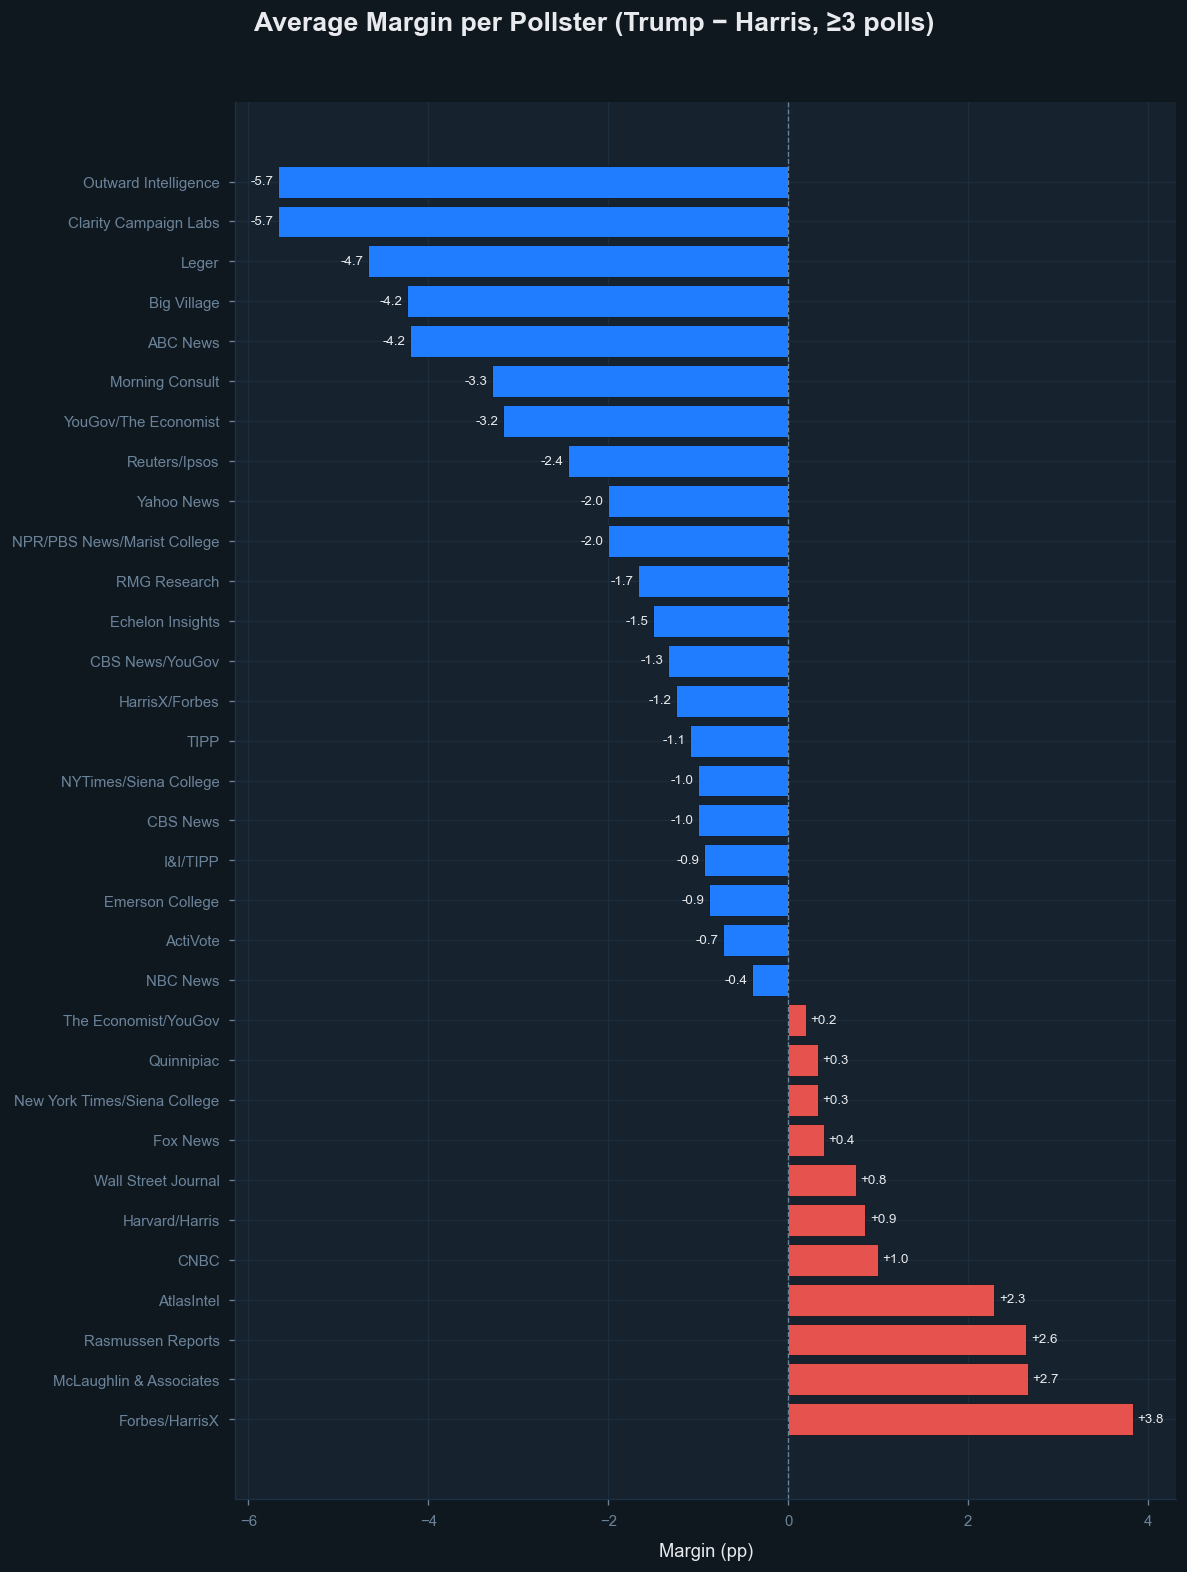

In [8]:
counts = df['Pollster_clean'].value_counts()
top    = counts[counts >= 3].index
stats  = (df[df['Pollster_clean'].isin(top)]
          .groupby('Pollster_clean')[['Trump','Harris']]
          .mean()
          .assign(Margin=lambda x: x['Trump'] - x['Harris'])
          .sort_values('Margin', ascending=False))

colors = [REPUBLICAN if m >= 0 else DEMOCRAT for m in stats['Margin']]
fig, ax = styled_fig(figsize=(10, max(4, len(stats)*0.4)),
                     title='Average Margin per Pollster (Trump − Harris, ≥3 polls)')
bars = ax.barh(stats.index, stats['Margin'], color=colors, edgecolor=BG_DARK)
ax.axvline(0, color=TEXT_MUTED, linewidth=0.8, linestyle='--')
for bar, val in zip(bars, stats['Margin']):
    ax.text(val + (0.05 if val>=0 else -0.05),
            bar.get_y() + bar.get_height()/2,
            f'{val:+.1f}', va='center', ha=('left' if val>=0 else 'right'),
            color=TEXT_PRIMARY, fontsize=8)
style_ax(ax, xlabel='Margin (pp)', grid_axis='x')
plt.tight_layout()
plt.show()

Clear house effects: Rasmussen, McLaughlin and Forbes/HarrisX give Trump +2 to +4 pp; Morning Consult, ABC News and Clarity give Harris +4 to +6 pp. Most pollsters point to Harris as frontrunner — aggregating across pollsters is essential to correct for house bias.

## Summary

In [9]:
df['dir_margin'] = df['Trump'] - df['Harris']
avg_margin = df['dir_margin'].mean()
leader = 'Trump' if avg_margin > 0 else 'Harris'

print(f"Polls          : {len(df)}")
print(f"Date range     : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Avg Trump      : {df['Trump'].mean():.1f}%")
print(f"Avg Harris     : {df['Harris'].mean():.1f}%")
print(f"Avg margin     : {avg_margin:+.2f} pp  ({leader} leads)")
print(f"Trump leads    : {(df['Trump'] > df['Harris']).sum()} polls")
print(f"Harris leads   : {(df['Trump'] < df['Harris']).sum()} polls")
print(f"Tied           : {(df['Trump'] == df['Harris']).sum()} polls")

Polls          : 256
Date range     : 2024-06-24 → 2024-11-04
Avg Trump      : 46.7%
Avg Harris     : 47.9%
Avg margin     : -1.16 pp  (Harris leads)
Trump leads    : 83 polls
Harris leads   : 151 polls
Tied           : 22 polls
